In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option('display.max_columns', None)

In [161]:
# reading data from source
train = pd.read_csv(r'C:\Kaggle_Competition\Playground\S6E3-Customer-Churn\data\raw\train.csv')
test = pd.read_csv(r'C:\Kaggle_Competition\Playground\S6E3-Customer-Churn\data\raw\test.csv')
exog = pd.read_csv(r'C:\Kaggle_Competition\Playground\S6E3-Customer-Churn\data\exog\IBM-Telco-Customer-Churn.csv')

In [162]:
# shape of data
print(f'Shape of train: {train.shape}')
print(f'Shape of test: {test.shape}')
print(f'Shape of exog: {exog.shape}')

Shape of train: (594194, 21)
Shape of test: (254655, 20)
Shape of exog: (7043, 21)


In [163]:
# check for nullity
print(f'Total null values in the train: {train.isna().sum().sum()}')
print(f'Total null values in the test: {test.isna().sum().sum()}')
print(f'Total null values in the exog: {exog.isna().sum().sum()}')

Total null values in the train: 0
Total null values in the test: 0
Total null values in the exog: 0


In [164]:
# check for duplicates
print(f'Total duplicates in the train: {train.duplicated().sum()}')
print(f'Total duplicates in the test: {test.duplicated().sum()}')
print(f'Total duplicates in the exog: {exog.duplicated().sum()}')

Total duplicates in the train: 0
Total duplicates in the test: 0
Total duplicates in the exog: 0


In [165]:
cat_cols = [
    'gender',
    'SeniorCitizen',
    'Partner', 
    'Dependents', 
    'PhoneService', 
    'MultipleLines', 
    'InternetService', 
    'OnlineSecurity', 
    'OnlineBackup', 
    'DeviceProtection', 
    'TechSupport', 
    'StreamingTV', 
    'StreamingMovies', 
    'Contract', 
    'PaperlessBilling', 
    'PaymentMethod', 
    #'Churn'
]

num_cols = [
    #'id',  
    'tenure', 
    'MonthlyCharges', 
    'TotalCharges'
]

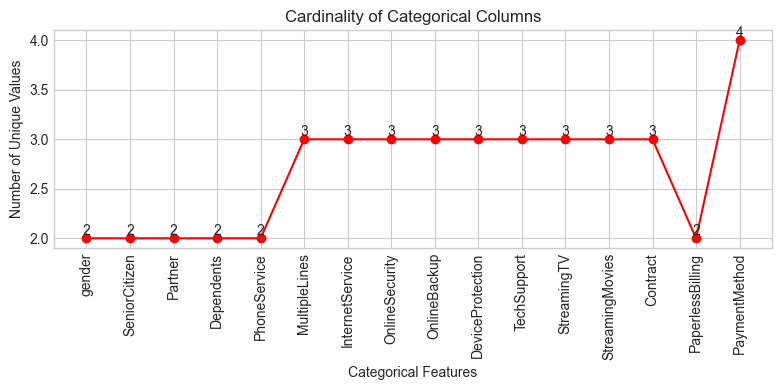

In [166]:
# Cardinality of categorical columns
cardinality = train[cat_cols].nunique()

plt.figure(figsize=(8, 4))
plt.plot(cardinality.index, cardinality.values, marker='o', color='red')

# Add value labels
for i, value in enumerate(cardinality.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.title('Cardinality of Categorical Columns')
plt.xlabel('Categorical Features')
plt.ylabel('Number of Unique Values')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

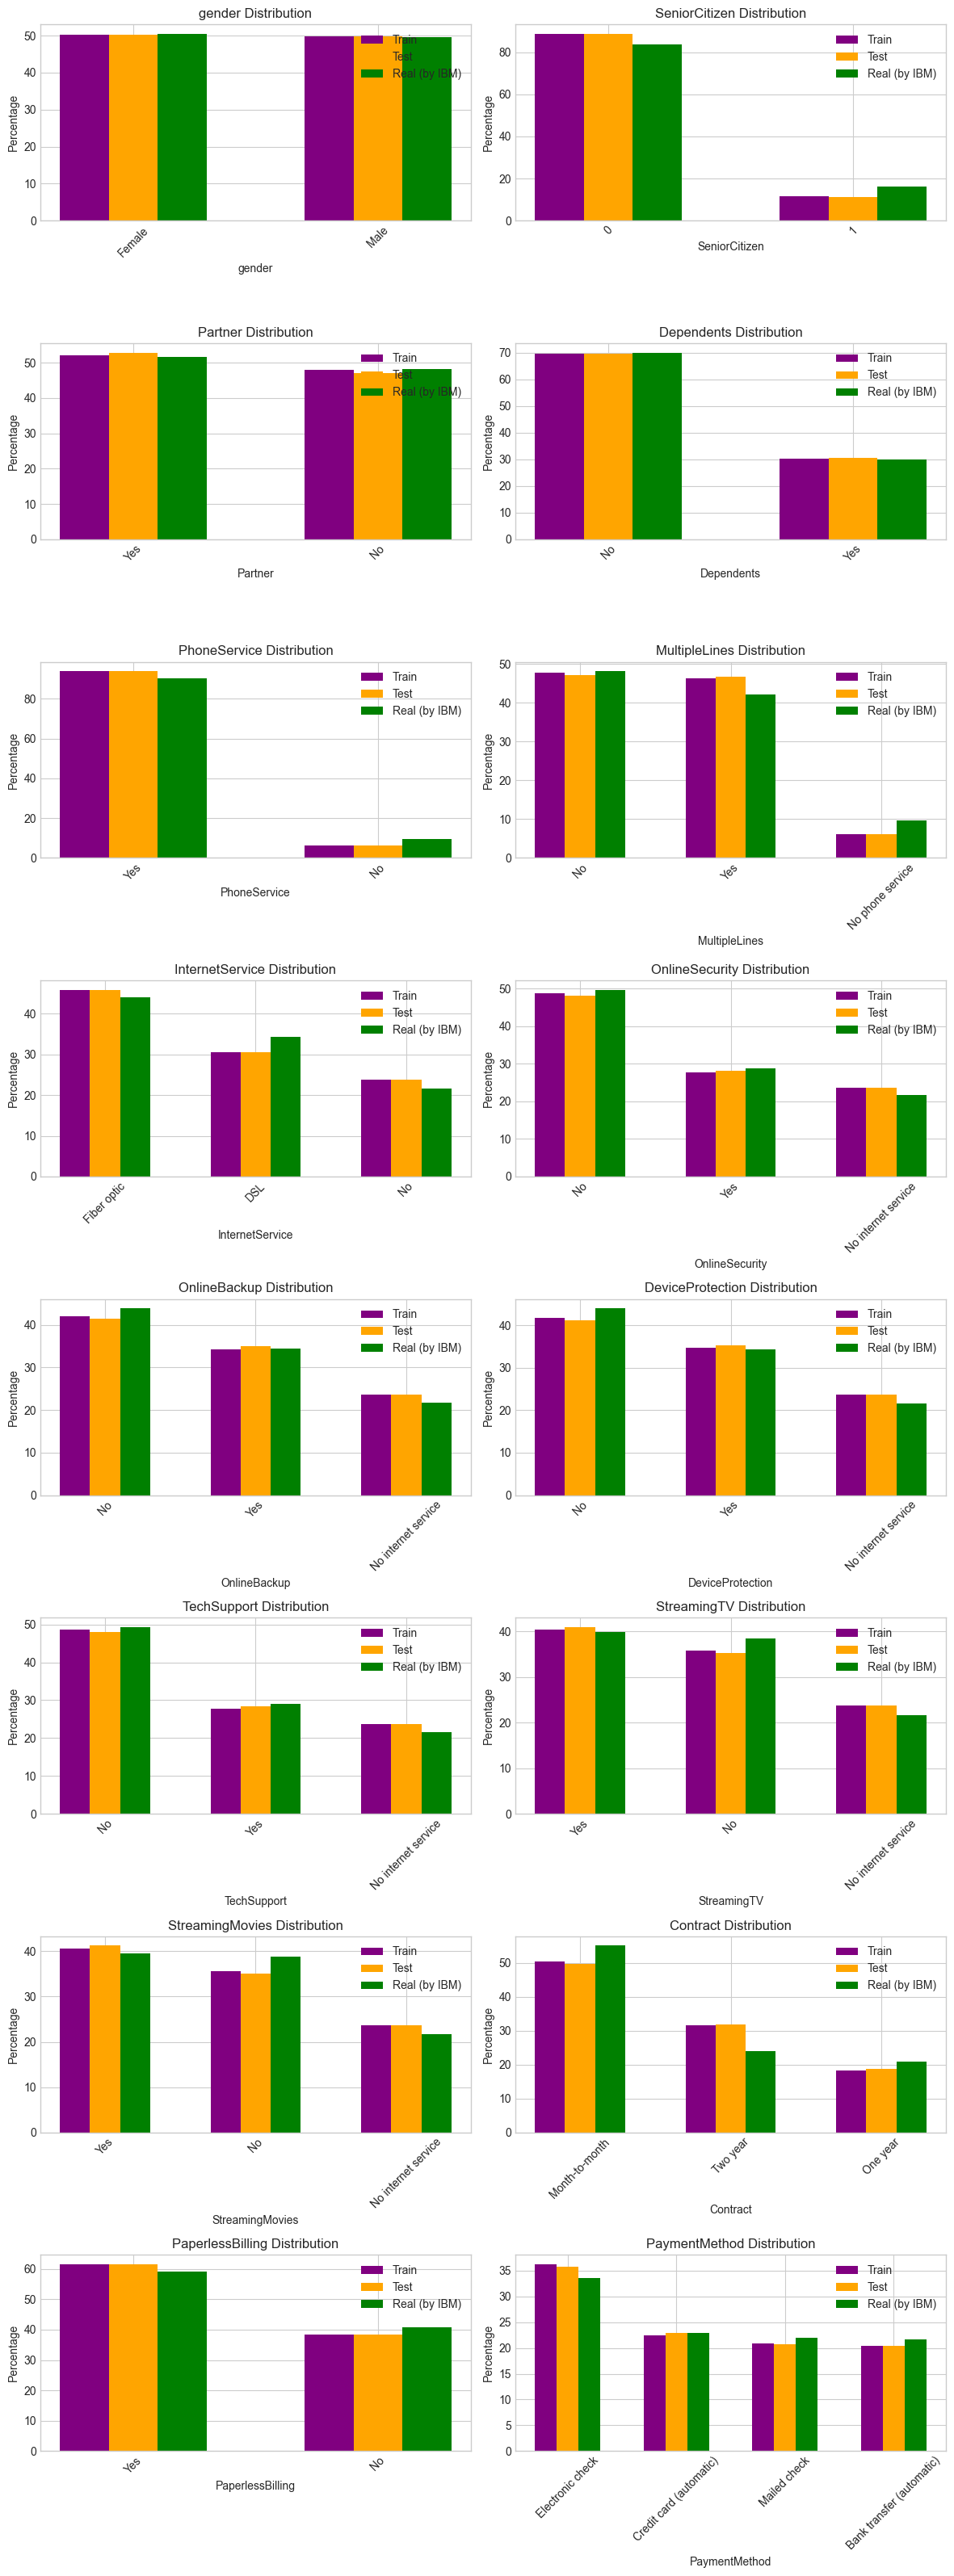

In [167]:
n = len(cat_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    train_counts = train[col].value_counts(normalize=True) * 100
    test_counts = test[col].value_counts(normalize=True) * 100
    exog_counts = exog[col].value_counts(normalize=True) * 100

    x = np.arange(len(train_counts.index))
    width = 0.20

    axes[i].bar(x - width, train_counts.values, width, label="Train", color="purple")
    axes[i].bar(x, test_counts.values, width, label="Test", color="orange")
    axes[i].bar(x + width, exog_counts.values, width, label="Real (by IBM)", color="green")

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(train_counts.index.astype(str))
    axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Percentage")
    axes[i].legend()

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

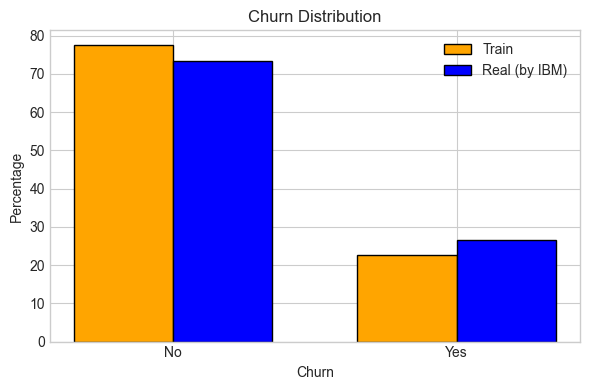

In [168]:
col = "Churn"

train_counts = train[col].value_counts(normalize=True) * 100
exog_counts = exog[col].value_counts(normalize=True) * 100

x = np.arange(len(train_counts.index))
width = 0.35

fig, ax = plt.subplots(figsize=(6,4))

# Train bars
ax.bar(x - width/2, train_counts.values, width,
       label="Train", color="orange", edgecolor="black")

# Exog bars
ax.bar(x + width/2, exog_counts.values, width,
       label="Real (by IBM)", color="blue", edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(train_counts.index.astype(str))

ax.set_title(f"{col} Distribution")
ax.set_xlabel(col)
ax.set_ylabel("Percentage")
ax.legend()

plt.tight_layout()
plt.show()